# Agrupamento de Dados com o Iris Dataset

Este projeto tem como objetivo aplicar técnicas de aprendizado não supervisionado, utilizando o algoritmo KMeans++, para realizar a clusterização das amostras de flores do conjunto de dados Iris. 

Embora o Iris Flower Dataset seja amplamente utilizado em problemas de classificação supervisionada, no qual contém rótulos de espécie para cada amostra, neste projeto ele será explorado de uma forma diferente: como um problema de aprendizado não supervisionado.

O [Iris Flower Dataset](https://www.kaggle.com/datasets/arshid/iris-flower-dataset) é um clássico da Ciência de Dados e contém informações sobre três espécies de flores (Setosa, Versicolor e Virginica), descritas por quatro atributos morfológicos: comprimento e largura das sépalas e pétalas.

O dataset utilizado foi obtido no Kaggle e será explorado com o objetivo de verificar se é possível identificar padrões naturais e segmentar corretamente as flores em grupos distintos, sem utilizar os rótulos de espécie durante o treinamento.

Este tipo de abordagem é útil, por exemplo, em cenários onde os rótulos não estão disponíveis e é necessário segmentar os dados de forma automática.

Após a criação dos agrupamentos, os resultados serão comparados com os rótulos reais (espécies) apenas para avaliação da qualidade do modelo, verificando se os clusters formados fazem sentido do ponto de vista biológico.

In [98]:
# Importar as bibliotecas necessarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

In [99]:
# Importar banco de dados
df = pd.read_csv('IRIS.csv')

In [100]:
# Analise preliminar do banco de dados
print(f'O banco de dados contem {df.shape[1]} colunas e {df.shape[0]} linhas.')

O banco de dados contem 5 colunas e 150 linhas.


In [101]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [103]:
df['species'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [104]:
# Contagem dos tipos de especies
iris_count = pd.crosstab(index=df['species'],
                        columns='count')
iris_count

col_0,count
species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


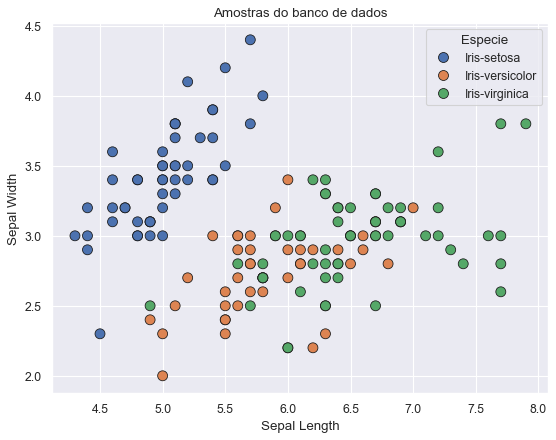

In [105]:
# Visualizacao grafica das amostras do banco de dados
plt.figure(figsize=(8,6), dpi=80)
sns.set(style='darkgrid')
sns.scatterplot(data=df,
               x='sepal_length',
               y='sepal_width',
               hue='species',
               palette='deep',
               s=80, edgecolor='k')
plt.title('Amostras do banco de dados')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.legend(title='Especie')
plt.show()


In [106]:
X = df.iloc[:, [0,1,2,3]].values

In [107]:
# Metodo de Cotovelo para encontrar o numero otimo de cluster
inertia_values = []

In [108]:
# Definir uma array com os valores de k
clusters_numbers = np.arange(1, 10, 1)

In [109]:
# Loop para obter e armazenar os valores de inércia atrelados a agrupamentos com partcionamentos distintos

for k in clusters_numbers:
    # Instacioar o o objeto KMeans com k grupos (clusters)
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42)

    # Realizar o agrupamento dos dados - treinamento do modelo de agrupamento
    kmeans.fit(X)

    # Armazenar o valor de inércia para o particionamento das asmotras em k grupos (clusters)
    inertia_values.append(kmeans.inertia_)

C:\Users\Izabella\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1411: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Izabella\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1411: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Izabella\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1411: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Izabella\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1411: UserWarning: KMeans is known to have a memory le

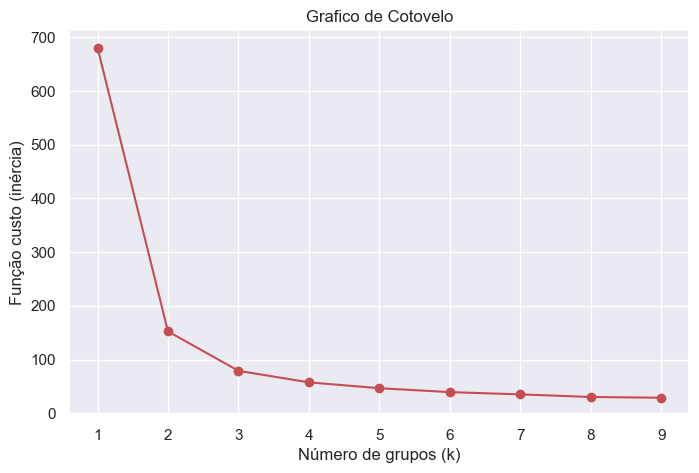

In [110]:
# Gerar gráfico de cotovelo
plt.figure(figsize=(8,5), dpi=100)

plt.plot(clusters_numbers, inertia_values, 'r-o')
plt.title('Grafico de Cotovelo')
plt.ylabel("Função custo (inércia)")
plt.xlabel("Número de grupos (k)")
plt.xticks(clusters_numbers)
plt.grid(True)
plt.show()

In [111]:
# Instanciar o objeto KMeans com os respectivos valores de k
kmeans = KMeans(n_clusters=3, init="k-means++", verbose=1, random_state=42)
y_kmeans= kmeans.fit_predict(X)

Initialization complete
Iteration 0, inertia 151.65999999999997.
Iteration 1, inertia 95.27318380102044.
Iteration 2, inertia 87.00356562736206.
Iteration 3, inertia 84.80172984452898.
Iteration 4, inertia 84.10217888865148.
Iteration 5, inertia 83.13638186876973.
Iteration 6, inertia 81.8390020677262.
Iteration 7, inertia 80.89577600000001.
Iteration 8, inertia 79.96297983461304.
Iteration 9, inertia 79.43376414532676.
Iteration 10, inertia 79.01070972222222.
Iteration 11, inertia 78.9450658259773.
Converged at iteration 11: strict convergence.


C:\Users\Izabella\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1411: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [112]:
# Identificar o valor final da função custo (inércia)
inertia = kmeans.inertia_
inertia

78.9450658259773

In [113]:
# Identificar as coordenadas finais dos centroides dos grupos
centroids = kmeans.cluster_centers_
centroids

array([[6.85384615, 3.07692308, 5.71538462, 2.05384615],
       [5.006     , 3.418     , 1.464     , 0.244     ],
       [5.88360656, 2.74098361, 4.38852459, 1.43442623]])

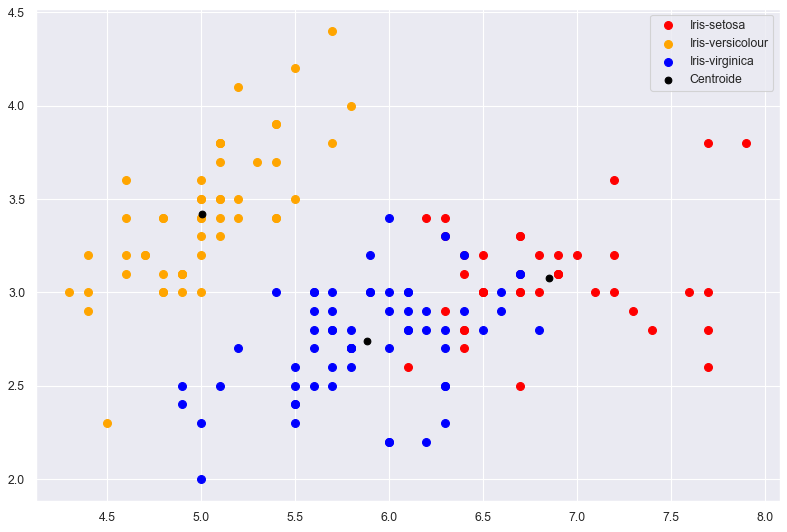

In [114]:
# Visualização gráfica da segmentação do banco de dados via k-means
plt.figure(figsize=(12,8), dpi=80)
sns.set(style='darkgrid')

plt.scatter(X[y_kmeans==0,0], X[y_kmeans==0,1], s=50, c='red', label='Iris-setosa')
plt.scatter(X[y_kmeans==1,0], X[y_kmeans==1,1], s=50, c='orange', label='Iris-versicolour')
plt.scatter(X[y_kmeans==2,0], X[y_kmeans==2,1], s=50, c='blue', label='Iris-virginica')

plt.scatter(centroids[:,0], centroids[:,1], c='black', label='Centroide')

plt.legend()

plt.show()

In [115]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import LabelEncoder
from scipy.stats import mode

# Transformar os rótulos reais (string) em números
encoder = LabelEncoder()
y_true = encoder.fit_transform(df['species'])

# O y_kmeans pode ter labels trocadas (ex: 0 ≠ setosa). Vamos “alinhar” as labels:
def map_clusters(y_true, y_pred):
    labels = np.zeros_like(y_pred)
    for i in range(3):  # número de clusters
        mask = (y_pred == i)
        labels[mask] = mode(y_true[mask], keepdims=True).mode[0]
    return labels

y_pred_aligned = map_clusters(y_true, y_kmeans)

# Avaliar
print("Acuracidade:", accuracy_score(y_true, y_pred_aligned))

Acuracidade: 0.8866666666666667


O modelo de KMeans obteve uma acurácia de 88%, um desempenho bastante satisfatório para este tipo de análise de agrupamento não supervisionado. Embora o modelo tenha apresentado resultados próximos aos rótulos reais, a precisão não foi perfeita. Isso se deve, possivelmente, à natureza das medições, que, apesar de serem relacionadas à morfologia das plantas, podem apresentar variações sutis entre as espécies. Além disso, como estamos lidando com um problema de aprendizado não supervisionado, o modelo foi desafiado a identificar padrões sem a utilização dos rótulos reais, o que pode influenciar a exatidão dos agrupamentos. No entanto, o desempenho do KMeans indica que a segmentação das flores seguiu padrões biológicos coerentes, o que valida a eficácia do algoritmo para este problema.